# S3 LST L2 data preparation
This script uses the downloaded Sentinel-3 data (for download see script `get_data_openeo_s#.ipynb`) for the lake_id 6 (Kangaarsuup Tasersua) and preprocesses it:
- concatonates the years to one stack
- clips by -500m buffred shoreline of lake 6
- masks out cloud pixels
- calculates some statistics about the lake temperature:
    - mean, median, std, count the number of pixels used for it (this can be used for quality filtering later on), calculate bootstrapped confidence intervals etc, calculate the mean uncertainty (from the given uncertainty per pixel)
- this is then written into a csv file to disc for later use in the script called `data_analysis`
- further down in this script there is some initial data visualisation and checking

To run this script, use the environment `openeo2`.



In [ ]:
# import modules
import openeo
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely as shp
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import cartopy
import glob

In [ ]:
# load data from folder structure
files = sorted(glob.glob("data_2017_2025/*.nc"))
print(files)

# storage list
datasets = []

for file in files:
    ds = xr.open_dataset(file)
    datasets.append(ds) # append 

#concat by time
data = xr.concat(datasets, dim = "t")

data

# read shareline of lake
lake = gpd.read_file(r'..\lake_polygons\lake_6_shoreline_shp\lake_shoreline.shp')
#lake.crs --> EPSG 4326 --> fine


# and inspect the data set
print(data["LST"].attrs)
print(data["LST_uncertainty"].attrs)
print(data["exception"].attrs)
print(data["confidence_in"].attrs)

# unfortunately no units given! --> but this is included in the metadata:
#connection.describe_collection(S3_LST_L2) # --> in script S3_get_data_openeo

# check time dimension
print(data.t.values.min())
print(data.t.values.max())

['data_2017_2025\\S3_LST_L2_2017.nc', 'data_2017_2025\\S3_LST_L2_2018.nc', 'data_2017_2025\\S3_LST_L2_2019.nc', 'data_2017_2025\\S3_LST_L2_2020.nc', 'data_2017_2025\\S3_LST_L2_2021.nc', 'data_2017_2025\\S3_LST_L2_2022.nc', 'data_2017_2025\\S3_LST_L2_2023.nc', 'data_2017_2025\\S3_LST_L2_2024.nc', 'data_2017_2025\\S3_LST_L2_2025.nc']


<positron-console-cell-3>:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.


{'long_name': 'LST', 'units': '', 'grid_mapping': 'crs'}
{'long_name': 'LST_uncertainty', 'units': '', 'grid_mapping': 'crs'}
{'long_name': 'exception', 'units': '', 'grid_mapping': 'crs'}
{'long_name': 'confidence_in', 'units': '', 'grid_mapping': 'crs'}
2016-12-31T23:41:00.000000000
2025-12-30T23:41:00.000000000


# mask out cloud pixels 
If the integer in confidence_int is ≥ 16384 (which is the int way of writing bit 14), the pixel is considered cloudy.

# ATTENTION: check the cloud filtering - I cannot find the source again where the cloud flag is mentioned. 

In [4]:
### apply the cloud filtering to temp and unc bands
cloudy = (data["confidence_in"] >= 2**14) # int of 14bit
data["LST_c_filtered"] = data["LST"].where(~cloudy)
data["LST_uncertainty_c_filtered"] = data["LST_uncertainty"].where(~cloudy)

## clip by -500m lake buffered shoreline

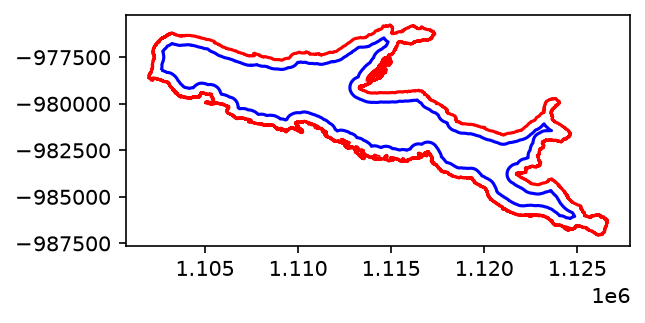

In [5]:
# make from xarray an rioxarray by defining crs and lon lat values
data = data.rio.write_crs("EPSG:4326")  
data = data.rio.set_spatial_dims(x_dim="x", y_dim="y")  

# buffer the lake shore with a minus buffer, so that the polygon shrinks, then redo
# reproject first the lake polygon to use m as unit
lake_5938 = lake.to_crs(5938)

# shrink inward by 500 meters using a negative buffer
lake_5938_buffered = lake_5938.geometry.buffer(-500)
# reconvert to 4326
lake_buffered = lake_5938_buffered.to_crs(4326)

# quick check of buffer
fig, ax = plt.subplots(figsize = (10, 2))
lake_5938.boundary.plot(color = "red", ax = ax)
lake_5938_buffered.boundary.plot(color = "blue", ax = ax)
plt.show()

#### finally: clip using buffered ########### 
data_clipped = data.rio.clip(lake_buffered.geometry, lake_buffered.crs, drop=True) # drop = True means that all NaN values (outside of lake are not stored any further)

### count the number of pixels in the respective time step (so after filetering)

In [6]:
# count pixels per time step
counts_per_timestep = data_clipped["LST_c_filtered"].count(dim = ("x", "y"))

### calculate the mean, median, mean uncertainty from cloud filtered variables

In [7]:
### calculate the temperature (mean/median of lake first)
mean = data_clipped["LST_c_filtered"].mean(("x", "y"))-273.15 # convert to celsius
median = data_clipped["LST_c_filtered"].median(("x", "y"))-273.15 # convert to celsius
uncertainty = data_clipped["LST_uncertainty_c_filtered"].mean(("x", "y"))
std = data_clipped["LST_c_filtered"].std(("x", "y"))

# make a proper pandas datetime object out of the median.t time dimension
data_clipped["t"] = pd.to_datetime(data_clipped["t"].values)

C:\Users\Lenovo\anaconda3\envs\openeo2\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### bootstrap confidence intervals:

In [ ]:
# flatten spatial dim into 1d array
flat_data = data_clipped["LST_c_filtered"] - 273.15  
flat_pixels = flat_data.stack(pixel=("x", "y"))

# bootstrap pars and storage
num_bootstraps = 1000  
ci_lower = []
ci_upper = []

# loop through each timestap
for tidx in range(len(flat_pixels.t)):
    # Get all pixel values for tidx, frop na
    timestep_pixels = flat_pixels.isel(t=tidx).values
    valid_pixels = timestep_pixels[~np.isnan(timestep_pixels)] # subset to get only valid pixels
    n_pixels = len(valid_pixels)
    
    # Handle edge cases (e.g., no data or too few pixels to bootstrap)
    if n_pixels < 5:  
        ci_lower.append(np.nan)
        ci_upper.append(np.nan)
        continue
        
    # make bootstrap samples with shape is (num_bootstraps, n_pixels)
    # pick at random with raplacement = T
    boot_samples = np.random.choice(valid_pixels, size=(num_bootstraps, n_pixels), replace=True)
    
    # compute median from bootstrap sample
    boot_medians = np.median(boot_samples, axis=1)
    
    # get 2.5 and 97.5t percentile
    ci_lower.append(np.percentile(boot_medians, 2.5))
    ci_upper.append(np.percentile(boot_medians, 97.5))

# back into xarray 
median = data_clipped["LST_c_filtered"].median(("x", "y")) - 273.15
median["t"] = pd.to_datetime(median["t"].values) # put back

# error bars relative to the median
boot_err_lower = median.values - np.array(ci_lower)
boot_err_upper = np.array(ci_upper) - median.values

# into 2xN array for yerr par in plt.errorbar
bootstrap_yerr = np.vstack([boot_err_lower, boot_err_upper])


### put all this together into a pandas dataframe

In [11]:
# create pandas dataframe to store all the 
results_S3 = pd.DataFrame({
    "datetime": pd.to_datetime(median.t.values),
    "lst_median_C": median.values,
    "lst_mean_C": mean.values,
    "lst_mean_uncertainty": uncertainty.values,
    "lst_std":std.values,
    "bootstrap_ci_lower": ci_lower,
    "bootstrap_ci_upper": ci_upper,
    "n_valid_pixels": counts_per_timestep.values,
})

results_S3 = results_S3.set_index("datetime")


In [ ]:
# write to csv file
results_S3.to_csv("S3_LST_L2_lake6.csv")

### visualize time series and bootstrapped CI

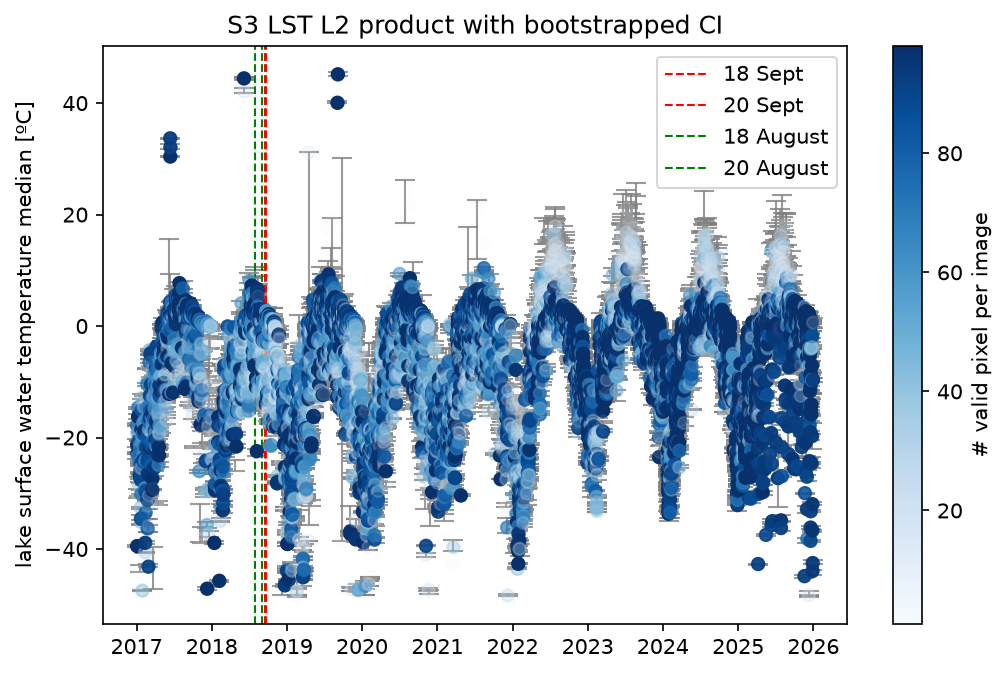

In [17]:

import matplotlib.pyplot as plt

# make proper datetime object
median["t"] = pd.to_datetime(median["t"].values)


# caluclate the alpha depending on number of pixels 
max_val = max(counts_per_timestep)

alpha_0_1 = counts_per_timestep/max_val
alpha_0_1

colors = np.zeros((len(alpha_0_1), 4))
colors[:, 0] = 0.0  # Red
colors[:, 1] = 0.0  # Green
colors[:, 2] = 1.0  # Blue
colors[:, 3] = alpha_0_1  # Alpha (transparency)

###########################
##### start plotting ######
###########################
fig, ax = plt.subplots(figsize=(8, 5))

# plot with bootstrapped CI
ax.errorbar(
    median.t.values,
    median.values,
    yerr=bootstrap_yerr,  # Uses the 95% CI from your bootstrap loop
    fmt="none",
    color="grey",
    alpha=0.8,
    capsize=5,
    elinewidth=1,
)

# points with cmap representing the numb of pixels
scatter = ax.scatter(
    median.t.values,
    median.values,
    c=counts_per_timestep.values,
    cmap="Blues",
    alpha=alpha_0_1,
    s=35,
    zorder=3,
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("# valid pixel per image")

plt.ylabel("lake surface water temperature median [ºC]")
plt.title("S3 LST L2 product with bootstrapped CI")

# add lines for time when comparsion images from ASTEr are available
sept_18 = pd.Timestamp("2018-09-18")
sept_20 = pd.Timestamp("2018-09-20")
plt.axvline(x=sept_18, color="red", linestyle="--", linewidth=1, label="18 Sept")
plt.axvline(x=sept_20, color="red", linestyle="--", linewidth=1, label="20 Sept")

# mark august period (best data quality)
august_first = pd.Timestamp("2018-08-01")
august_last = pd.Timestamp("2018-08-31")
plt.axvline(x=august_first, color="green", linestyle="--", linewidth=1, label="18 August")
plt.axvline(x=august_last, color="green", linestyle="--", linewidth=1, label="20 August")

plt.legend()
plt.show()


### zoom in for more in depth evaluation: 
There are two dates when there is a close image from ASTER:
from ASTER08_LSWT.ASTER08_data_download import Sept_12
- 12 Sept
- 19 Sept 

<positron-console-cell-18>:9: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "." (-> marker='.'). The keyword argument will take precedence.


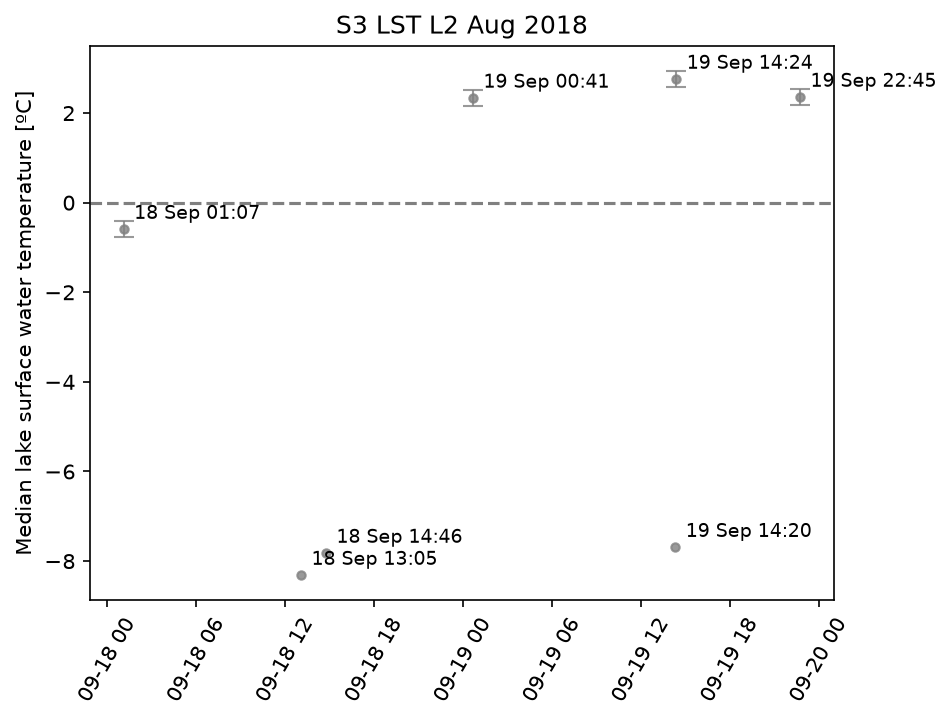

<positron-console-cell-18>:51: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "." (-> marker='.'). The keyword argument will take precedence.


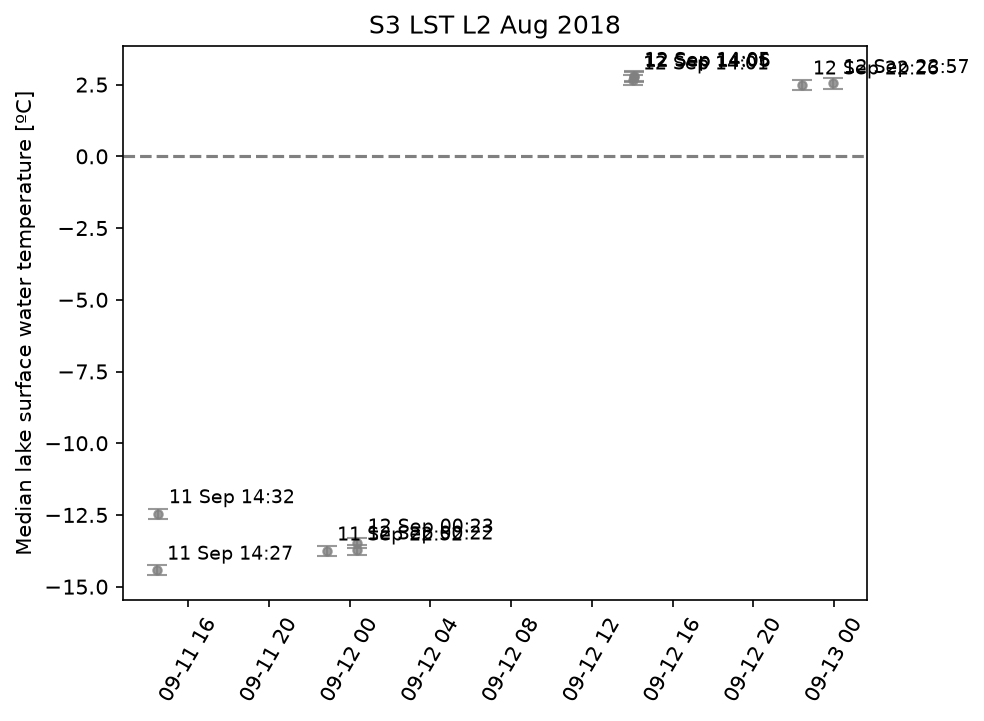

In [18]:
# 1. Select August from the original xarray objects first
median_sept = median.sel(t=slice(sept_18, sept_20))
uncertainty_sept = uncertainty.sel(t=slice(sept_18, sept_20))


# 3. Plotting
plt.axhline(y = 0, color = "grey", linestyle = "--")

plt.errorbar(
    median_sept.t.values,
    median_sept.values,
    yerr = uncertainty_sept.values, 
    marker = ".",
    color="grey",
    alpha=0.8,
    capsize=5,
    elinewidth=1, markersize = 8, fmt = "."
)

# 3. Add time (HH:MM) next to each point
for t, value in zip(median_sept.t.values, median_sept.values):
    time_label = pd.Timestamp(t).strftime("%d %b %H:%M")
    
    plt.annotate(
        time_label,
        (t, value),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.ylabel("Median lake surface water temperature [ºC]")
plt.xlabel("")
plt.title("S3 LST L2 Aug 2018")
plt.xticks(rotation=60)
plt.show()

###################################
##### do this for 12 Sept:###########
sept_11 = pd.Timestamp("2018-09-11")
sept_13 = pd.Timestamp("2018-09-13")

# 1. Select August from the original xarray objects first
median_sept = median.sel(t=slice(sept_11, sept_13))
uncertainty_sept = uncertainty.sel(t=slice(sept_11, sept_13))


# 3. Plotting
plt.axhline(y = 0, color = "grey", linestyle = "--")

plt.errorbar(
    median_sept.t.values,
    median_sept.values,
    yerr = uncertainty_sept.values, 
    marker = ".",
    color="grey",
    alpha=0.8,
    capsize=5,
    elinewidth=1, markersize = 8, fmt = "."
)

# 3. Add time (HH:MM) next to each point
for t, value in zip(median_sept.t.values, median_sept.values):
    time_label = pd.Timestamp(t).strftime("%d %b %H:%M")
    
    plt.annotate(
        time_label,
        (t, value),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.ylabel("Median lake surface water temperature [ºC]")
plt.xlabel("")
plt.title("S3 LST L2 Aug 2018")
plt.xticks(rotation=60)
plt.show()



consider the following effects:
- day/night
- is ice (so icebergs from the calving) actually filtered out?
- mixed pixel 

### plot the respective aggregated data points (median) as map they have been derived from

Text(0.5, 1.0, '2018-03-26T22:33:00.000000000, S3 LST ºC: -18.04')

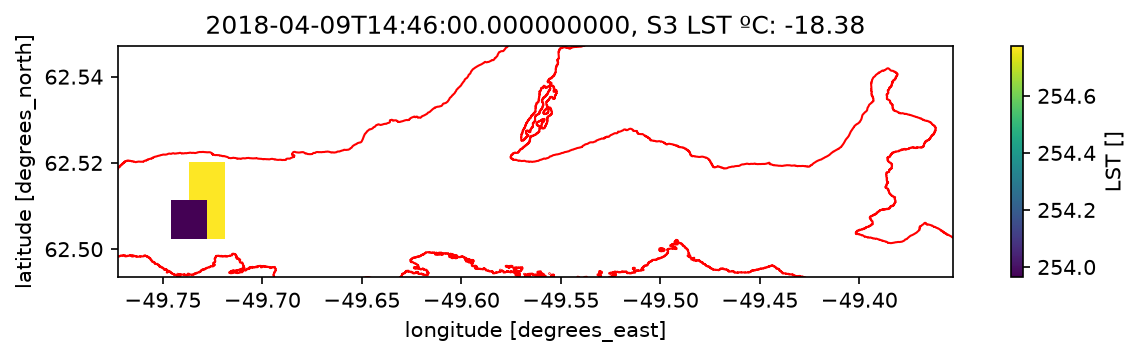

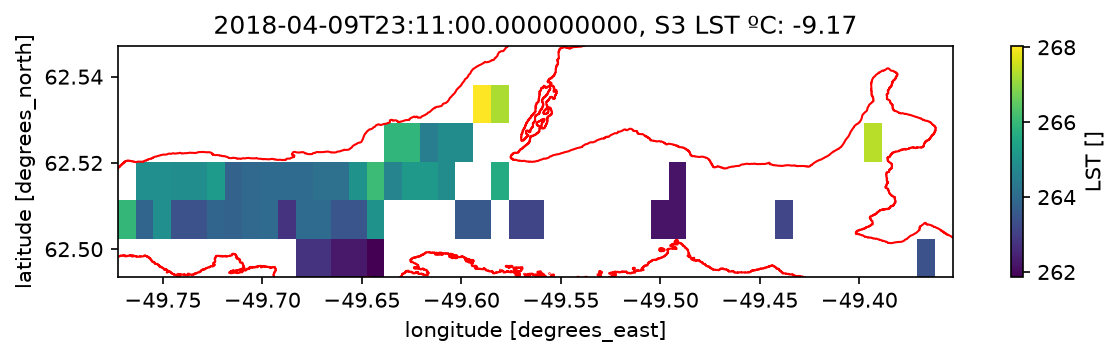

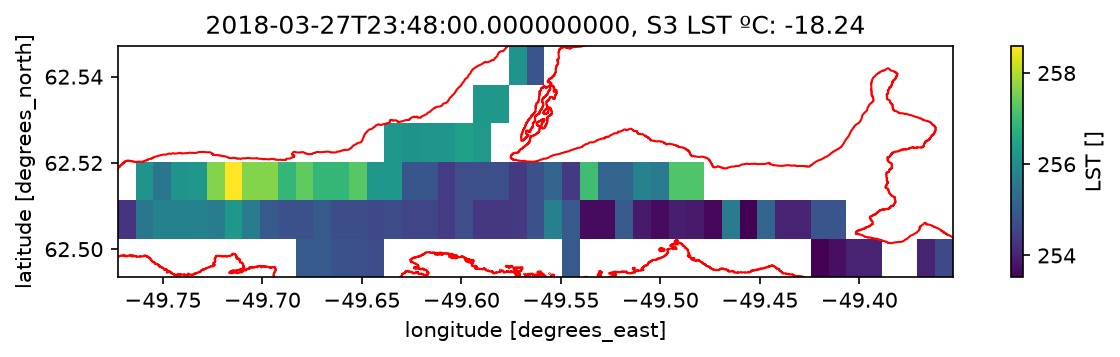

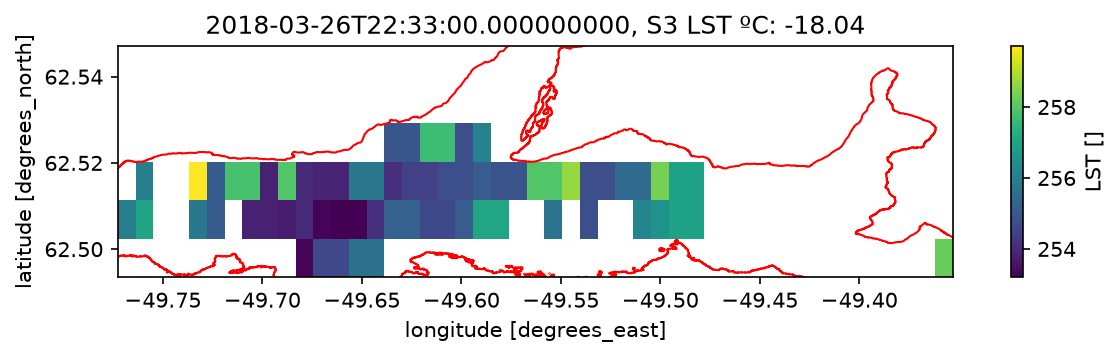

In [19]:

temp = data_clipped["LST_c_filtered"].isel(t = 1171).median(dim = ("x", "y"))-273.15
# plot for inspection
fig,ax=plt.subplots(figsize = (10, 2)) 
data_clipped["LST_c_filtered"].isel(t = 1171).plot()
lake.plot(ax=ax, facecolor='none', edgecolor = 'red') 
plt.title(f"{data_clipped['LST_c_filtered'].isel(t = 1171).t.values}, S3 LST ºC: {temp.values:.2f}")

# seems to work
#print(data_clipped["LST_c_filtered"].isel(t = 1172).median(dim = ("x", "y"))-273.15)

temp = data_clipped["LST_c_filtered"].isel(t = 1172).median(dim = ("x", "y"))-273.15
# plot for inspection
fig,ax=plt.subplots(figsize = (10, 2)) 
data_clipped["LST_c_filtered"].isel(t = 1172).plot()
lake.plot(ax=ax, facecolor='none', edgecolor = 'red') 
plt.title(f"{data_clipped['LST_c_filtered'].isel(t = 1172).t.values}, S3 LST ºC: {temp.values:.2f}")


temp = data_clipped["LST_c_filtered"].isel(t = 1139).median(dim = ("x", "y"))-273.15
# plot for inspection
fig,ax=plt.subplots(figsize = (10, 2)) 
data_clipped["LST_c_filtered"].isel(t = 1139).plot()
lake.plot(ax=ax, facecolor='none', edgecolor = 'red') 
plt.title(f"{data_clipped['LST_c_filtered'].isel(t = 1139).t.values}, S3 LST ºC: {temp.values:.2f}")

temp = data_clipped["LST_c_filtered"].isel(t = 1136).median(dim = ("x", "y"))-273.15
# plot for inspection
fig,ax=plt.subplots(figsize = (10, 2)) 
data_clipped["LST_c_filtered"].isel(t = 1136).plot()
lake.plot(ax=ax, facecolor='none', edgecolor = 'red') 
plt.title(f"{data_clipped['LST_c_filtered'].isel(t = 1136).t.values}, S3 LST ºC: {temp.values:.2f}")
